# Machine Learning - python scikit-learn

## Etapy: preprocessing, learning, testowanie, przewidywanie

In [ ]:
# Przykład preprocesingu

import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Prosty zbiór danych (np. wzrost w cm)
data = np.array([[160], [170], [180], [190]])

# 2. Inicjalizacja estymatora
scaler = StandardScaler()

# 3. Estymacja parametrów (wywołanie metody fit)
scaler.fit(data)

# 4. Odczytanie wyestymowanych parametrów
print(f"Wyestymowana średnia: {scaler.mean_[0]}")
print(f"Wyestymowana wariancja: {scaler.var_[0]}")

# 5. Zastosowanie parametrów (transformacja)
scaled_data = scaler.transform(data)
print("\nDane po standaryzacji:")
print(scaled_data)

Wyestymowana średnia: 175.0
Wyestymowana wariancja: 125.0

Dane po standaryzacji:
[[-1.34164079]
 [-0.4472136 ]
 [ 0.4472136 ]
 [ 1.34164079]]


### Perceptron

Niech $x$ będzie wektorem danych wejściowych i $y$ wektorem wartości, których się uczymy (target). Szukamy wektora $w$, takiego, że hiperpłaszczyzna $w*x=0$ najlepiej przybliża wartości $y$.

Błąd j-tego współczynnika w $w$ wyliczamy jako $$ \Delta w_j = \eta (y - \hat{y} )x_j,$$
gdzie $\eta$ współczynnik szybkości nauki, $y$ -- wartości docelowe, $\hat{y}$ -- aktualny wynik działania perceptrona, $x_j$ - $j$-ty bit wejścia.

Uwaga. Perceptron ma zero-jedynkową aktywację błędu. Może też nie zbiegać do konkretnej wartości, w procesie uczenia może się cały czas przełączać.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# 1. Załadowanie zbioru danych
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Podział na zbiór treningowy i testowy (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Skalowanie cech (istotne dla zbieżności perceptronu)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# 4. Inicjalizacja i trenowanie modelu
# tol: kryterium zatrzymania, eta0: współczynnik uczenia
ppn = Perceptron(max_iter=40, eta0=0.2, random_state=42)
ppn.fit(X_train_std, y_train)

# 5. Predykcja i ewaluacja
y_pred = ppn.predict(X_test_std)
accuracy = accuracy_score(y_test, y_pred)

print(f"Dokładność klasyfikatora: {accuracy:.2%}")

Dokładność klasyfikatora: 80.00%


Ponieważ dane nie są separowalne liniowo, nie możemy spodziewać się bezbłędnego działania.

Wizualizacja działania perceptrona podana jest poniżej.

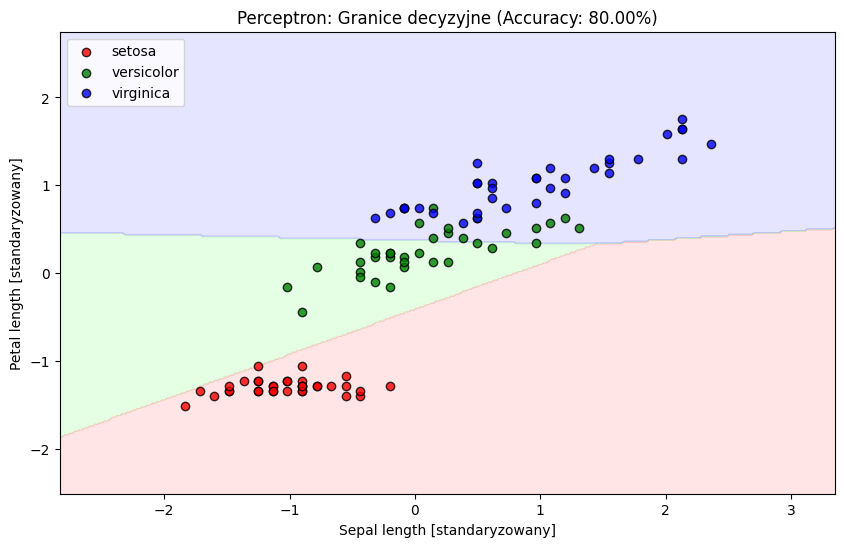

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Wybór dwóch cech do wizualizacji (indeksy 0 i 2)
X_plot = X_train_std[:, [0, 2]]
ppn.fit(X_plot, y_train)

# 2. Przygotowanie siatki (meshgrid)
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 3. Predykcja dla każdego punktu siatki
Z = ppn.predict(np.array([xx.ravel(), yy.ravel()]).T)
Z = Z.reshape(xx.shape)

# 4. Rysowanie wykresu
plt.figure(figsize=(10, 6))
cmap = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

# Nakładanie punktów ze zbioru testowego
for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X_plot[y_train == cl, 0], y=X_plot[y_train == cl, 1],
                alpha=0.8, c=['red', 'green', 'blue'][idx],
                label=iris.target_names[cl], edgecolor='black')

plt.title(f"Perceptron: Granice decyzyjne (Accuracy: {accuracy:.2%})")
plt.xlabel('Sepal length [standaryzowany]')
plt.ylabel('Sepal length [standaryzowany]')
plt.legend(loc='upper left')
plt.show()

## Adaline - ADAptive LInear  NEuron

Zmiana wobec perceptronu to liniowa funkcja aktywacji neuronu
$$ \phi(w^T x )   = w^Tx. $$

W perceptronie odpowiedź neuronu i funkcja błędu i-tej współrzędnej wektora $w$ była zero-jedynkowa.

Teraz mamy różniczkowalną funkcję błędu wektora wag $w$
$$ J(w)=\frac{1}{2}(\Sigma_{i}(y^i - \phi(z^i))). $$

Wartość korekty wagi $w_j$ wyliczamy korzystając z pochodnej funkcji błędu po $w_j$.

Regresja log. jest mniej podatna na wartości odstające, działa stabilniej.

---



In [ ]:
# Implementacja Adaline

import numpy as np

class AdalineGD:
    def __init__(self, eta=0.01, n_iter=50):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            # Obliczenie wyjścia liniowego: z = w^T * x
            net_input = self.net_input(X)
            # W Adaline funkcja aktywacji jest liniowa: phi(z) = z
            output = net_input
            errors = (y - output)

            # Aktualizacja wag na podstawie całego zbioru (Batch Gradient Descent)
            # Delta w = eta * X^T * błąd
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()

            # Funkcja kosztu: Suma Kwadratów Błędów (SSE)
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

Accuracy: 71.00%


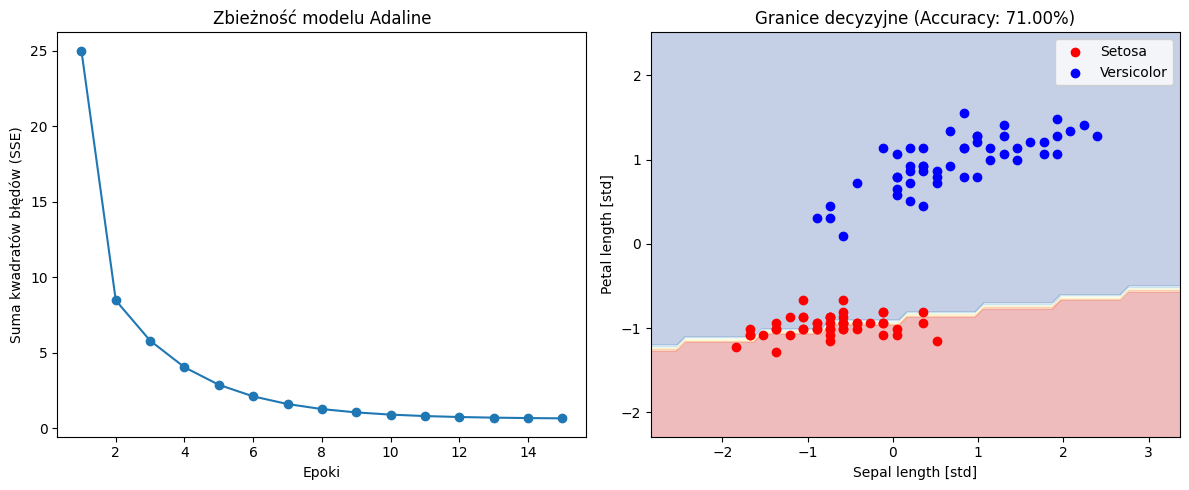

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

# Załadowanie danych (tylko 2 klasy dla czystego modelu binarnego)
iris = datasets.load_iris()
X = iris.data[:100, [0, 2]] # Sepal length, Petal length
y = iris.target[:100]
y = np.where(y == 0, 0, 1) # Klasy 0 i 1

# Standardaryzacja (Adaline wymaga jej do poprawnej zbieżności gradientu)
sc = StandardScaler()
X_std = sc.fit_transform(X)

# Inicjalizacja i trening
ada = AdalineGD(eta=0.01, n_iter=15)
ada.fit(X_std, y)

# --- SPRAWDZANIE ACCURACY ---
def get_accuracy(model, X, y):
    y_pred = model.predict(X)
    return np.mean(y_pred == y)

accuracy = get_accuracy(ada, X_std, y)
print(f"Accuracy: {accuracy:.2%}")

# --- WIZUALIZACJA ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Wykres 1: Spadek funkcji kosztu (SSE)
ax[0].plot(range(1, len(ada.cost_) + 1), ada.cost_, marker='o')
ax[0].set_xlabel('Epoki')
ax[0].set_ylabel('Suma kwadratów błędów (SSE)')
ax[0].set_title('Zbieżność modelu Adaline')

# Wykres 2: Granice decyzyjne
x_min, x_max = X_std[:, 0].min() - 1, X_std[:, 0].max() + 1
y_min, y_max = X_std[:, 1].min() - 1, X_std[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = ada.predict(np.array([xx.ravel(), yy.ravel()]).T)
Z = Z.reshape(xx.shape)

ax[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
ax[1].scatter(X_std[y==0, 0], X_std[y==0, 1], color='red', label='Setosa')
ax[1].scatter(X_std[y==1, 0], X_std[y==1, 1], color='blue', label='Versicolor')
ax[1].set_xlabel('Sepal length [std]')
ax[1].set_ylabel('Petal length [std]')
ax[1].set_title(f'Granice decyzyjne (Accuracy: {accuracy:.2%})')
ax[1].legend()

plt.tight_layout()
plt.show()

W scikit-learn mamy model Adaline
w SGDClassifier:

from sklearn.linear_model import SGDClassifier

Możemy wtedy ustawić:
loss='squared_error', model wtedy zachowuje się jak Adaline (Stochastic GD)

adaline_sgd = SGDClassifier(loss='squared_error', learning_rate='constant', eta0=0.01, max_iter=1000)

adaline_sgd.fit(X_train_std, y_train)

# Regresja logistyczna

Funkcja aktywacji nie jest już liniowa ale
$$\varphi(z) = \frac{z}{1+e^{-z}},$$
gdzie $z=w^T x$, przewidywana waratość.

Regresja logistyczna zwraca prawdopodobieństwo $p$, że wejście $x$ należy do określonej klasy.

Gdybyśmy chcieli określi ścisłą granicę moglibyśmy przyjąć wartość $\frac{1}{2}$.

$$log(\frac{p}{1-p}) = w^Tx.$$







In [ ]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Załadowanie zbioru danych
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Standaryzacja cech (kluczowa dla poprawnej interpretacji wag)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# 4. Inicjalizacja i trening modelu
# multi_class='ovr' (One-vs-Rest) pozwala na jasną interpretację wag dla każdej klasy
lr = LogisticRegression(C=10.0, solver='lbfgs', multi_class='ovr', random_state=42)
lr.fit(X_train_std, y_train)

# 5. Predykcja i dokładność
y_pred = lr.predict(X_test_std)
print(f"Dokładność modelu: {accuracy_score(y_test, y_pred):.2%}\n")

# 6. Analiza wag (współczynników) modelu
weights_df = pd.DataFrame(
    lr.coef_,
    columns=iris.feature_names,
    index=iris.target_names
)

print("Interpretacja wag dla poszczególnych klas (zestandaryzowane):")
print(weights_df.T)

Dokładność modelu: 91.11%

Interpretacja wag dla poszczególnych klas (zestandaryzowane):
                     setosa  versicolor  virginica
sepal length (cm) -1.569287   -0.191036   0.329602
sepal width (cm)   1.556246   -1.533149  -1.052560
petal length (cm) -2.716748    2.308186   4.458082
petal width (cm)  -2.510642   -2.183642   6.131020


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


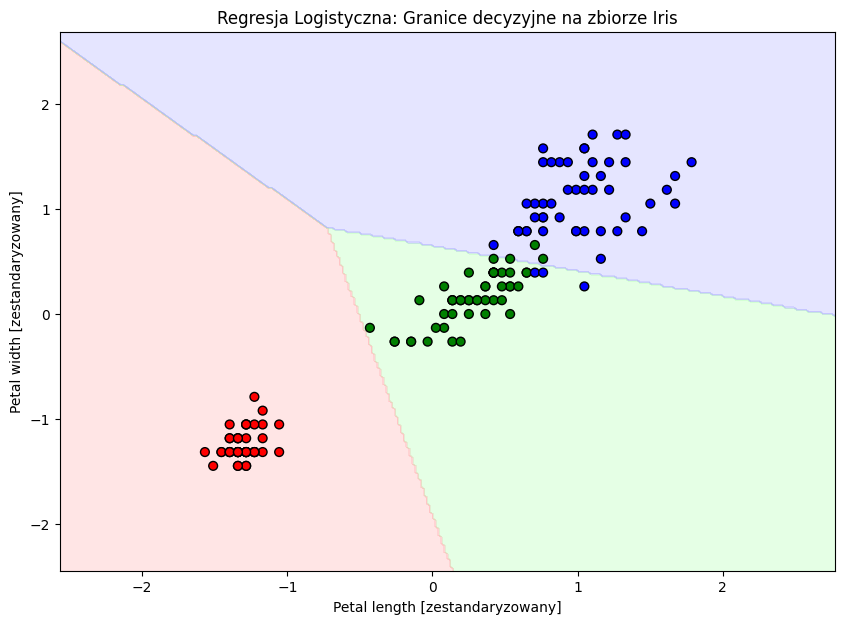

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# 1. Przygotowanie danych (2 cechy dla wizualizacji 2D)
iris = datasets.load_iris()
X = iris.data[:, [2, 3]] # petal length, petal width
y = iris.target

# 2. Standaryzacja
sc = StandardScaler()
X_std = sc.fit_transform(X)

# 3. Trening modelu
lr = LogisticRegression(C=1.0, solver='lbfgs', multi_class='ovr')
lr.fit(X_std, y)

# 4. Tworzenie siatki do rysowania granic
x_min, x_max = X_std[:, 0].min() - 1, X_std[:, 0].max() + 1
y_min, y_max = X_std[:, 1].min() - 1, X_std[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 5. Predykcja dla całej płaszczyzny
Z = lr.predict(np.array([xx.ravel(), yy.ravel()]).T)
Z = Z.reshape(xx.shape)

# 6. Rysowanie wykresu
plt.figure(figsize=(10, 7))
colors = ('#FFAAAA', '#AAFFAA', '#AAAAFF')
cmap = ListedColormap(colors[:len(np.unique(y))])

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
plt.scatter(X_std[:, 0], X_std[:, 1], c=y, cmap=ListedColormap(['red', 'green', 'blue']),
            edgecolor='black', s=40)

plt.xlabel('Petal length [zestandaryzowany]')
plt.ylabel('Petal width [zestandaryzowany]')
plt.title('Regresja Logistyczna: Granice decyzyjne na zbiorze Iris')
plt.show()

# Drzewa decyzyjne

Dzielimy zbiór danych za pomocą decyzji (testów), które układamy w formę drzewa.

Naszym celem jest maksymalizacja ,,information gain'' (IG), zysku informacyjnego.

$$ IG(D_p, f) = I(D_p) - \Sigma_{j=1}^m (N_j/ N_p) I(D_j),$$
gdzie $D_p, D_j$ to zbiory danych w rodzicu i dzieciach, $I$ to miara "nieczystości" węzła, $N_p, N_j$ ilość elementów w węźle rodzica i dzieciach.

## Miary nieczystości

Entropia węzła $t$:

$$I_H(t)= - \Sigma_{i=1}^c p(i|t)\log_2(p(i|t).$$

Gini

$$I_G(t) = \Sigma_{i=1}^c p(i|t)(1-p(i|t)) = 1 - \Sigma_{i=1}^c p(i|t)^2.
$$


Dokładność: 91.111111111%


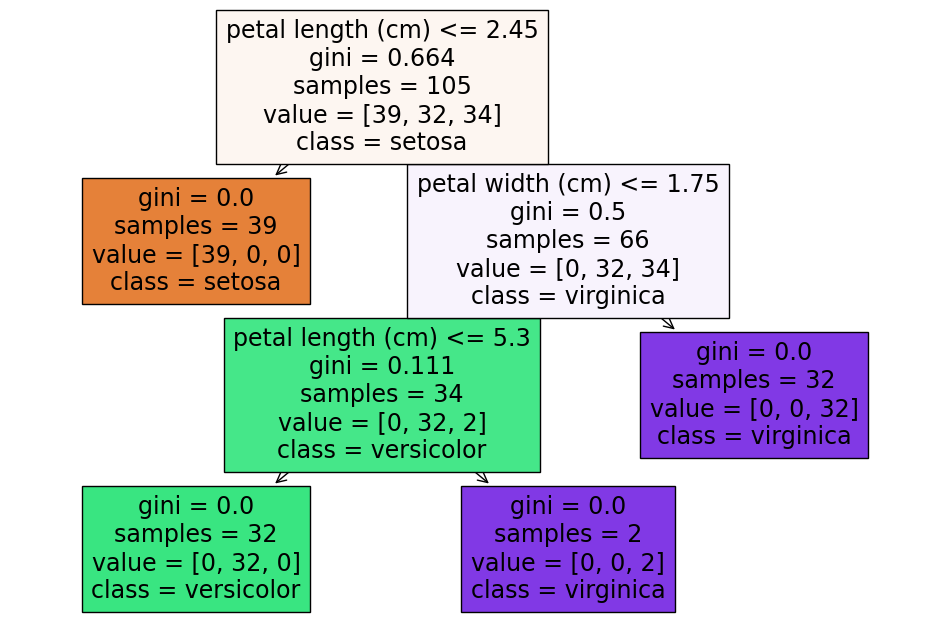

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Załadowanie i podział danych
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

# 2. Inicjalizacja i trening modelu
# criterion='entropy' (miara zysku informacyjnego) lub 'gini' (domyślnie)
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)

# 3. Ewaluacja
y_pred = tree_clf.predict(X_test)
print(f"Dokładność: {accuracy_score(y_test, y_pred):.2%}")

# 4. Wizualizacja struktury logicznej drzewa
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

## Problemy przy korzystaniu z drzew decyzyjnych

Jeśli nie ograniczymy wysokości drzewa nasz model się ,,przeuczyć'': będzie miał bardzo mały (lub wręcz zerowy) błąd na danych treningowych ale duży błąd na daych testowych. Drzewo wtedy dopasowuje się do danych treningowych ale wyprowadza odpowiednich uogólnień.



Aby temu zaradzić możemy ograniczać złożoność drzew:

- ograniczanie głębokości drzewa,
- ograniczanie liczby liści,
- ograniczanie (od dołu) liczby elementów, przy których następuje podział węzła.

Możemy też stworzyć wiele drzew (las) na losowo wybranych podzbiorach treningowych. Odpowiedź jest (uśrednioną/większościową) odpowiedzią wszystkich drzew w lesie.

# Klasteryzacja

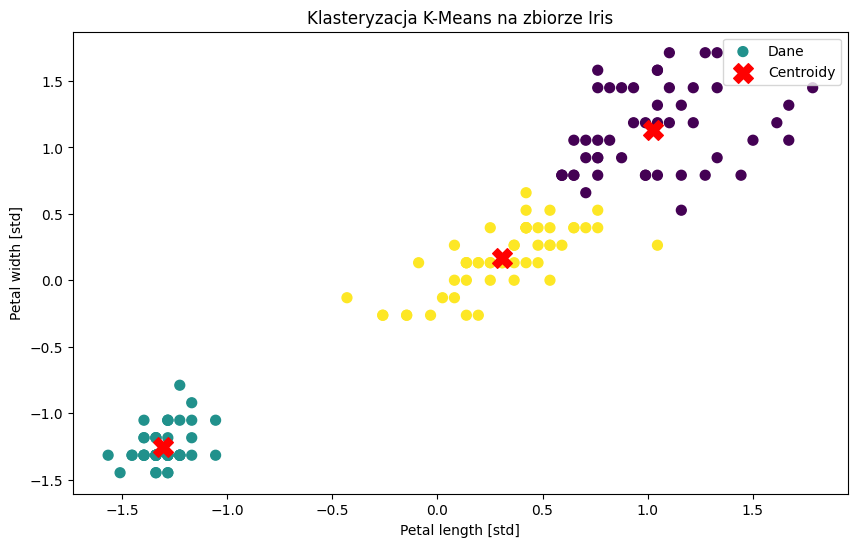

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Załadowanie danych (ignorujemy target 'y' podczas uczenia)
iris = load_iris()
X = iris.data[:, [2, 3]] # Wybieramy cechy płatków (petal) dla lepszej separacji

# 2. Standaryzacja (klasteryzacja opiera się na dystansie euklidesowym)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 3. Inicjalizacja i trening modelu K-Means
# Zakładamy k=3, ponieważ wiemy o 3 gatunkach (w praktyce używa się metody łokcia)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_std)

# 4. Pobranie wyników
y_kmeans = kmeans.predict(X_std) # Przewidywane klastry
centroids = kmeans.cluster_centers_ # Współrzędne środków ciężkości grup

# 5. Wizualizacja
plt.figure(figsize=(10, 6))
plt.scatter(X_std[:, 0], X_std[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Dane')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroidy')

plt.xlabel('Petal length [std]')
plt.ylabel('Petal width [std]')
plt.title('Klasteryzacja K-Means na zbiorze Iris')
plt.legend()
plt.show()

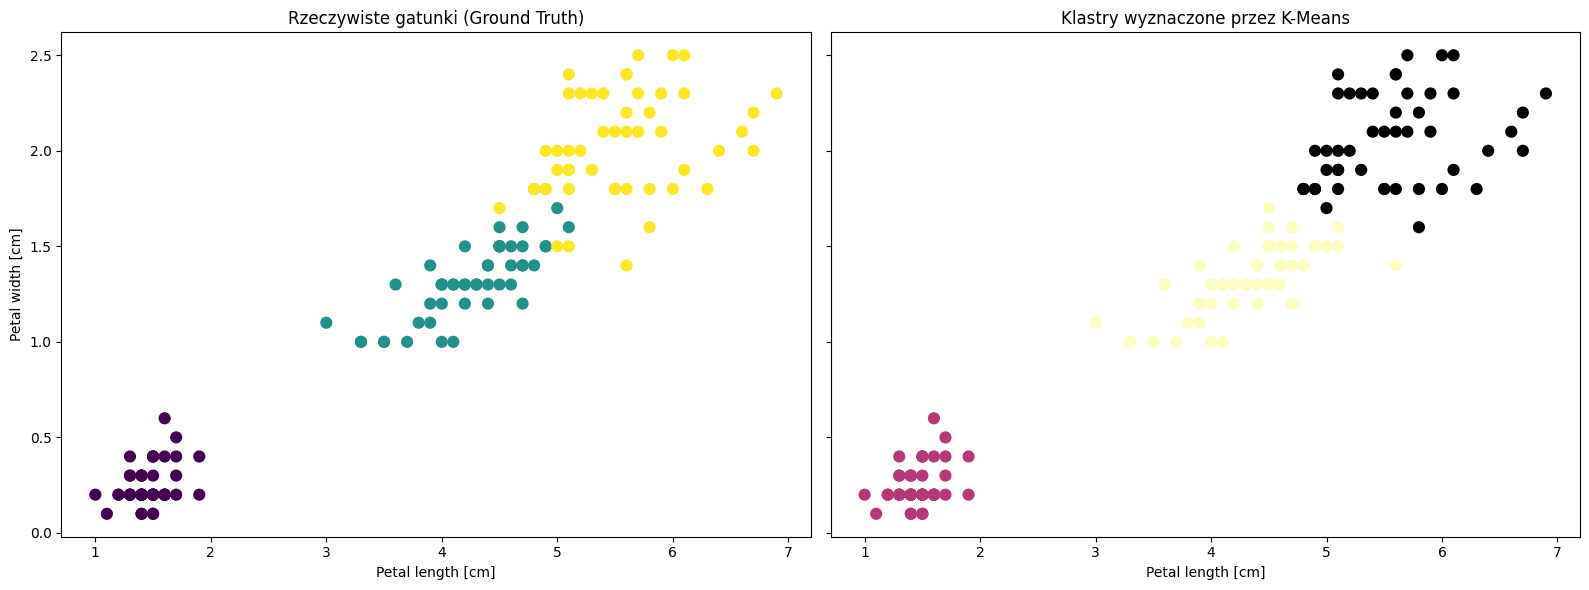

In [ ]:
# Porównanie klastrów z rzeczywistymi gatunkami

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Przygotowanie danych
iris = load_iris()
X = iris.data[:, [2, 3]]  # Wybieramy długość i szerokość płatka (petal)
y_actual = iris.target    # Rzeczywiste gatunki

# 2. Standaryzacja i klasteryzacja
X_std = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_transform(X_std).argmin(axis=1) # Przypisanie do klastrów

# 3. Wizualizacja porównawcza
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Wykres 1: Rzeczywiste gatunki
scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y_actual, cmap='viridis', s=60)
ax1.set_title("Rzeczywiste gatunki (Ground Truth)")
ax1.set_xlabel("Petal length [cm]")
ax1.set_ylabel("Petal width [cm]")

# Wykres 2: Wynik klasteryzacji K-Means
scatter2 = ax2.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='magma', s=60)
ax2.set_title("Klastry wyznaczone przez K-Means")
ax2.set_xlabel("Petal length [cm]")

plt.tight_layout()
plt.show()

## Wyznacznie optymalnej liczby klastrów

- Metoda łokcia - szukamy ilości klastrów, dla których zaczyna szybko zwalniać spadek sumy odległości punktów od centrów klastrów.

- Analiza sylwetki - sprawdzamy jak blisko punktów z jednego klastra są punkty z innych klastrów.



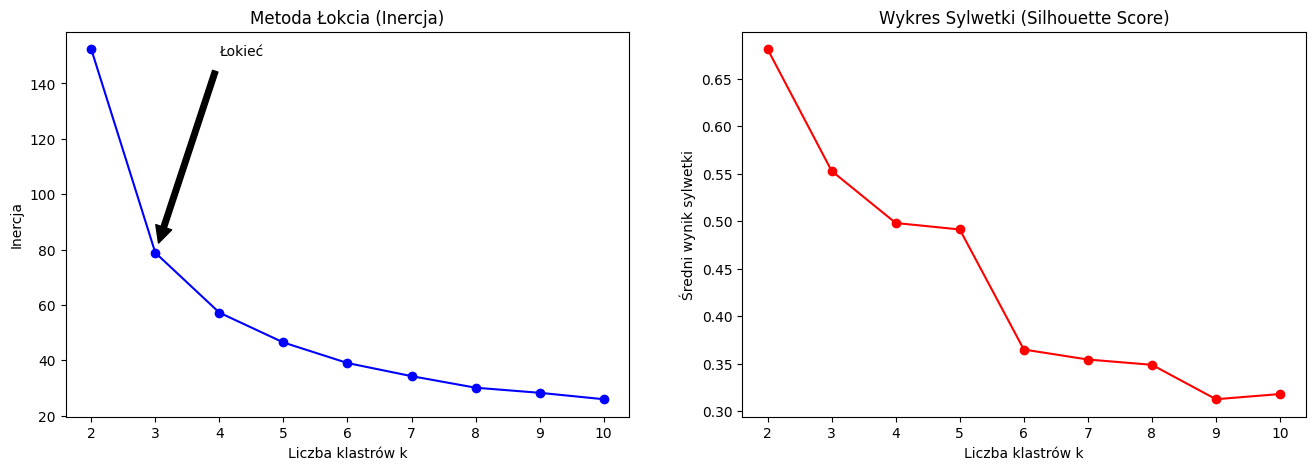

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

X = load_iris().data
inertias = []
silhouette_avgs = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_avgs.append(silhouette_score(X, kmeans.labels_))

# Wizualizacja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Wykres łokcia
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Metoda Łokcia (Inercja)')
ax1.set_xlabel('Liczba klastrów k')
ax1.set_ylabel('Inercja')
ax1.annotate('Łokieć', xy=(3, inertias[1]), xytext=(4, 150),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Wykres sylwetki
ax2.plot(k_range, silhouette_avgs, 'ro-')
ax2.set_title('Wykres Sylwetki (Silhouette Score)')
ax2.set_xlabel('Liczba klastrów k')
ax2.set_ylabel('Średni wynik sylwetki')

plt.show()

## Algorytm DBSCAN - samodzielne wyznaczenie liczby klastrów

Wyznacza klastry na podstawie parametrów

eps - maksymalna odległość dla sąsiadujących wierzchołków,
min_samples - minimalny rozmiar grupy.

Pozwala na wykrywanie elementów niepasujących do grupy.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_iris().data)

# Algorytm sam zdecyduje o liczbie klastrów na podstawie eps
# eps - odległość maksymalna dla punktów, które mogą być sąsiadami
# min_samples - minimalna liczność grupy
db = DBSCAN(eps=0.5, min_samples=5).fit(X)

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"Wyznaczona liczba klastrów: {n_clusters}")

Wyznaczona liczba klastrów: 2


/tmp/ipykernel_17216/1048097460.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('magma')(np.linspace(0, 1, len(unique_labels)))


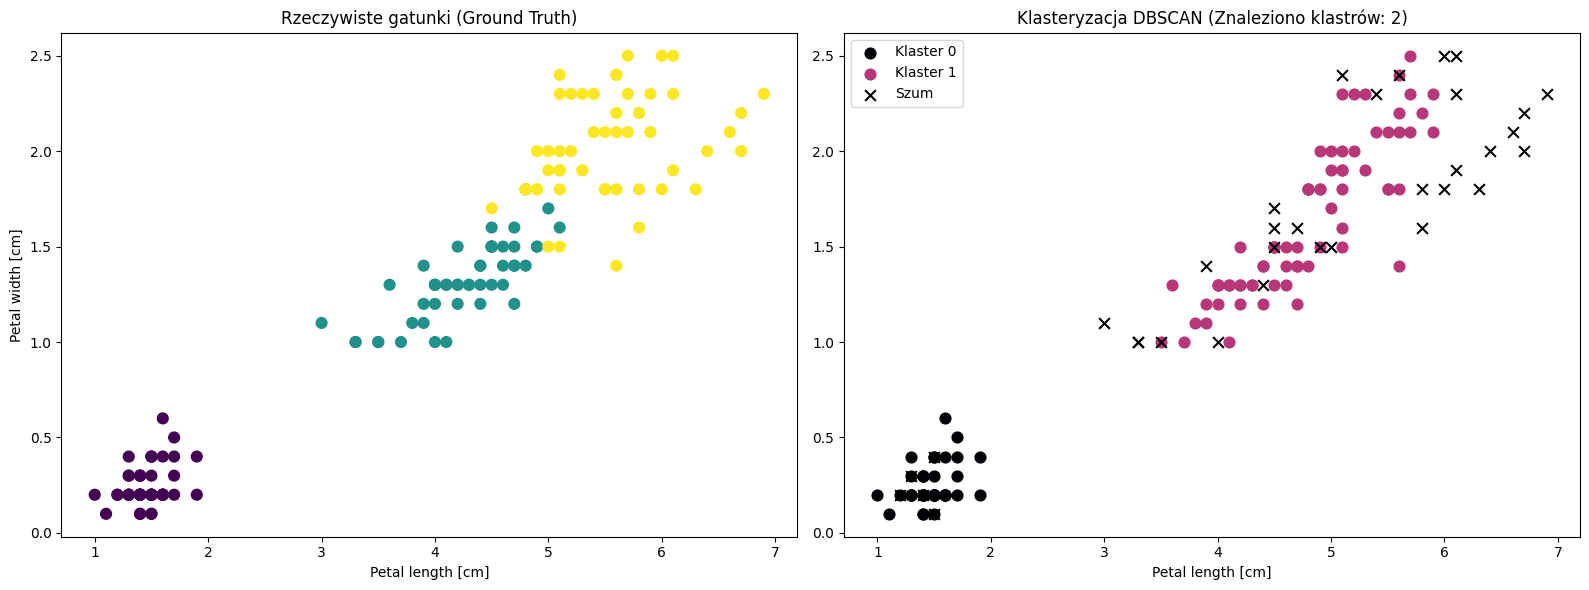

In [ ]:
# Porównanie z podziałem rzeczywistym

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Przygotowanie danych (używamy wszystkich cech do klastrowania, ale wizualizujemy 2)
iris = load_iris()
X = iris.data
y_actual = iris.target

# 2. Skalowanie - DBSCAN jest ekstremalnie czuły na skalę (parametr eps)
X_std = StandardScaler().fit_transform(X)

# 3. Model DBSCAN
# eps: promień sąsiedztwa, min_samples: min. liczba punktów by utworzyć rdzeń
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_std)

# 4. Wizualizacja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Wykres rzeczywistych gatunków
ax1.scatter(X[:, 2], X[:, 3], c=y_actual, cmap='viridis', s=60)
ax1.set_title("Rzeczywiste gatunki (Ground Truth)")
ax1.set_xlabel("Petal length [cm]")
ax1.set_ylabel("Petal width [cm]")

# Wykres DBSCAN
# Punkty szumu (etykieta -1) wizualizujemy na czarno (marker 'x')
unique_labels = set(y_dbscan)
colors = plt.cm.get_cmap('magma')(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Czarny dla szumu
        marker = 'x'
        label = 'Szum'
    else:
        marker = 'o'
        label = f'Klaster {k}'

    class_member_mask = (y_dbscan == k)
    ax2.scatter(X[class_member_mask, 2], X[class_member_mask, 3],
                color=tuple(col), marker=marker, s=60, label=label)

ax2.set_title(f"Klasteryzacja DBSCAN (Znaleziono klastrów: {len(unique_labels) - (1 if -1 in y_dbscan else 0)})")
ax2.set_xlabel("Petal length [cm]")
ax2.legend()

plt.tight_layout()
plt.show()

# Przykład estymacji za pomocą regresji liniowej

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Dane: X (cechy), y (target)
# Relacja: y = 2*x + 1
X = np.array([[1], [2], [3], [4]])
y = np.array([3, 5, 7, 9])

# 2. Inicjalizacja estymatora
model = LinearRegression()

# 3. PROCES UCZENIA (fit)
# Model minimalizuje błąd i estymuje parametry w oraz b
model.fit(X, y)

# 4. Sprawdzenie, czego nauczył się model
print(f"Wyestymowana waga (w): {model.coef_[0]:.1f}")
print(f"Wyestymowany punkt przecięcia (b): {model.intercept_:.1f}")

# 5. Predykcja dla nowej wartości
new_x = np.array([[10]])
prediction = model.predict(new_x)
print(f"\nPredykcja dla x=10: {prediction[0]:.1f} (Oczekiwane: 21)")

Wyestymowana waga (w): 2.0
Wyestymowany punkt przecięcia (b): 1.0

Predykcja dla x=10: 21.0 (Oczekiwane: 21)
